In [1]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import uniform, randint, loguniform

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from xgboost import XGBClassifier, DMatrix, XGBRegressor
from category_encoders import TargetEncoder

import sys
print(sys.executable)

/usr/bin/python3


In [3]:
## Only use this for Google Colab
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('drive/MyDrive/oldAIboy/houseprice')

Mounted at /content/drive


In [4]:
traindata = pd.read_csv("data/train.csv")
print("Full train dataset shape is {}".format(traindata.shape))
testdata = pd.read_csv("data/test.csv")
print("Full test dataset shape is {}".format(testdata.shape))

Full train dataset shape is (1460, 81)
Full test dataset shape is (1459, 80)


###### note: possible further FE tests: 1. bucket numberical feats (df[num_feat].apply(cat_func)); 2.normalize num feats; 3. try other models (regression, KNN)


### EDA - understand the data

##### EDA notes:
###### data distribution: found many relevant features such as SquareFeet/area,room counts,bathrms, garage, porch area etc. may be useful to create more powerful features by combining them
###### Features with high NA: some cat predictors have high NA% (PoolQC,MiscFeature,Alley,Fence,MasVnrType,FireplaceQu), some num features also have high NA% (LotFrontage), need to review the feature importance.
###### NA findings: garage features and bsmt features show the same NA%, may indicating the subjects are just NOT AVAILABLE. Should treat as 'None' /a separate class (tree ensemble can easily take advantage)
###### Many cat features have very few unique values (CentralAir, Street, Alley, Utilities etc.), some num features also have low nunique (HalfBath,BsmtHalfBath,BsmtFullBath), could conduct a process of feature selection to decide if they should be used for model training.

#### EDA 1: Data initial view - data overview, NA values, value variation // traindata, testdata

In [9]:
## check train df info
traindata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
##check numerical features's distribution for traindata
traindata.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [ ]:
##check numerical features's distribution for testdata
testdata.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1459.0,2190.000000,421.321334,1461.0,1825.50,2190.0,2554.50,2919.0
MSSubClass,1459.0,57.378341,42.746880,20.0,20.00,50.0,70.00,190.0
LotFrontage,1232.0,68.580357,22.376841,21.0,58.00,67.0,80.00,200.0
LotArea,1459.0,9819.161069,4955.517327,1470.0,7391.00,9399.0,11517.50,56600.0
OverallQual,1459.0,6.078821,1.436812,1.0,5.00,6.0,7.00,10.0
OverallCond,1459.0,5.553804,1.113740,1.0,5.00,5.0,6.00,9.0
YearBuilt,1459.0,1971.357779,30.390071,1879.0,1953.00,1973.0,2001.00,2010.0
YearRemodAdd,1459.0,1983.662783,21.130467,1950.0,1963.00,1992.0,2004.00,2010.0
MasVnrArea,1444.0,100.709141,177.625900,0.0,0.00,0.0,164.00,1290.0
BsmtFinSF1,1458.0,439.203704,455.268042,0.0,0.00,350.5,753.50,4010.0


In [ ]:
###check available data types - 43 categorical and 38 numerical
traindata.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [ ]:
## 43 categorical features
print(f'number of cat featurs: {traindata.select_dtypes(include=['object']).columns.shape}')
traindata.select_dtypes(include=['object']).columns

number of cat featurs: (43,)


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [ ]:
## 37 categorical features ('Id' is not a feature)
print(f'number of numerical featurs: {traindata.select_dtypes(exclude=['object']).columns.shape}')
traindata.select_dtypes(exclude=['object']).columns

number of numerical featurs: (38,)


Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [ ]:
### check features' NA% and nunique
# # note: many features have high NA% and low nunique - need to check if they are useful
colsinfotrain = pd.DataFrame(traindata.dtypes, columns=['dtype'])
colsinfotrain['NAcnt'] = traindata.isnull().sum()
colsinfotrain['NA%'] = colsinfotrain['NAcnt']/traindata.shape[0]
colsinfotrain['nunique'] = traindata.nunique()
colsinfotrain.sort_values(by=['NA%','nunique'], ascending=False, inplace=True)
colsinfotrain.head(15)

,dtype,NAcnt,NA%,nunique
PoolQC,object,1453,0.995205,3
MiscFeature,object,1406,0.963014,4
Alley,object,1369,0.937671,2
Fence,object,1179,0.807534,4
MasVnrType,object,872,0.597260,3
FireplaceQu,object,690,0.472603,5
LotFrontage,float64,259,0.177397,110
GarageYrBlt,float64,81,0.055479,97
GarageType,object,81,0.055479,6
GarageQual,object,81,0.055479,5


In [ ]:
## check features with high NA% NA findings: garage features and bsmt features show the same or similar NA rate, may indicating garage/basement are just NOT AVAILABLE for those properties!
## If this is true, it would be good to separate them as a 'None' class, since this info may be a strong signal of lower house price, easier for tree ensemble models to learn
colsinfotrain.iloc[:30]

,dtype,NAcnt,NA%,nunique
PoolQC,object,1453,0.995205,3
MiscFeature,object,1406,0.963014,4
Alley,object,1369,0.937671,2
Fence,object,1179,0.807534,4
MasVnrType,object,872,0.597260,3
FireplaceQu,object,690,0.472603,5
LotFrontage,float64,259,0.177397,110
GarageYrBlt,float64,81,0.055479,97
GarageType,object,81,0.055479,6
GarageQual,object,81,0.055479,5


In [ ]:
##some features (especially categorical features) have low nunique - need to evaluate their importance (using boxplot)
colsinfotrain.sort_values(by='nunique').iloc[:30]

,dtype,NAcnt,NA%,nunique
CentralAir,object,0,0.000000,2
Street,object,0,0.000000,2
Alley,object,1369,0.937671,2
Utilities,object,0,0.000000,2
PavedDrive,object,0,0.000000,3
HalfBath,int64,0,0.000000,3
BsmtHalfBath,int64,0,0.000000,3
LandSlope,object,0,0.000000,3
GarageFinish,object,81,0.055479,3
PoolQC,object,1453,0.995205,3


In [ ]:
### investigate testdata's column infos (dtype, NAcnt etc, nunique)
colsinfotest = pd.DataFrame(testdata.dtypes, columns=['dtype'])
colsinfotest['NAcnt'] = testdata.isnull().sum()
colsinfotest['NA%'] = colsinfotest['NAcnt']/testdata.shape[0]
colsinfotest['nunique'] = testdata.nunique()
colsinfotest.sort_values(by=['NA%','nunique'], ascending=False, inplace=True)
colsinfotest

,dtype,NAcnt,NA%,nunique
PoolQC,object,1456,0.997944,2
MiscFeature,object,1408,0.965045,3
Alley,object,1352,0.926662,2
Fence,object,1169,0.801234,4
MasVnrType,object,894,0.612748,3
...,...,...,...,...
HalfBath,int64,0,0.000000,3
KitchenAbvGr,int64,0,0.000000,3
PavedDrive,object,0,0.000000,3
Street,object,0,0.000000,2


In [ ]:
##check features' low variation
colsinfotest.sort_values(by='nunique').iloc[:30]

,dtype,NAcnt,NA%,nunique
Utilities,object,2,0.001371,1
PoolQC,object,1456,0.997944,2
Street,object,0,0.000000,2
CentralAir,object,0,0.000000,2
Alley,object,1352,0.926662,2
MasVnrType,object,894,0.612748,3
PavedDrive,object,0,0.000000,3
MiscFeature,object,1408,0.965045,3
GarageFinish,object,78,0.053461,3
LandSlope,object,0,0.000000,3


#### Reorg the data to prepare next steps' data EDA and modeling // traindata->X_train_combo, ylog; testdata -> X_test

In [5]:
##separate X and y: create X_train_combo and ylog
## X_train_combo will be split into X_train and X_val later
X_train_combo = traindata.drop('SalePrice', axis=1)
## apply log to target to better evaluate the model
ylog = np.log(traindata['SalePrice'])

## set up the dataset for final submission
X_test = testdata.copy(deep=True) ##create a data copy

In [6]:
print(f'Check if traindata and testdata columns are the same, the result is: {X_train_combo.columns.equals(X_test.columns)}')

Check if traindata and testdata columns are the same, the result is: True


In [7]:
X_train_combo.set_index('Id',inplace=True)
X_test.set_index('Id',inplace=True)

print(X_train_combo.shape)
print(X_test.shape)

(1460, 79)
(1459, 79)


#### EDA 2: Visualize data - obtain deeper understanding of the data (potential values of each features, correlation among features etc.)

In [ ]:
#### separate numerical and categorical features
num_features = X_train_combo.select_dtypes(include=[np.number])
cat_features = X_train_combo.select_dtypes(include=['object', 'category'])
print(f'num_features shape are {num_features.shape}')
print(f'cat_features shape are {cat_features.shape}')

num_features shape are (1460, 36)
cat_features shape are (1460, 43)


##### scatter plot upon numerical features
###### Some features seem to have strong correlation with sales price: OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,TotRmsAbvGrd, GarageArea
###### A lot of features are correlated such as SF/Area features and room count features. Maybe a good idea to combine them to shape new features.
###### some year related features such as 'YearBuilt' and 'YearRemodAdd' could be transformed into a recency index.

In [ ]:
feature_importances_df.iloc[-20:]

,Feature,Importance
59,EnclosedPorch,0.001369
26,ExterCond,0.001352
65,YrSold,0.001336
35,HeatingQC,0.001336
37,Electrical,0.001145
32,BsmtFinType2,0.001106
14,HouseStyle,0.000991
2,LotFrontage,0.000961
8,LotConfig,0.000931
5,LotShape,0.000835


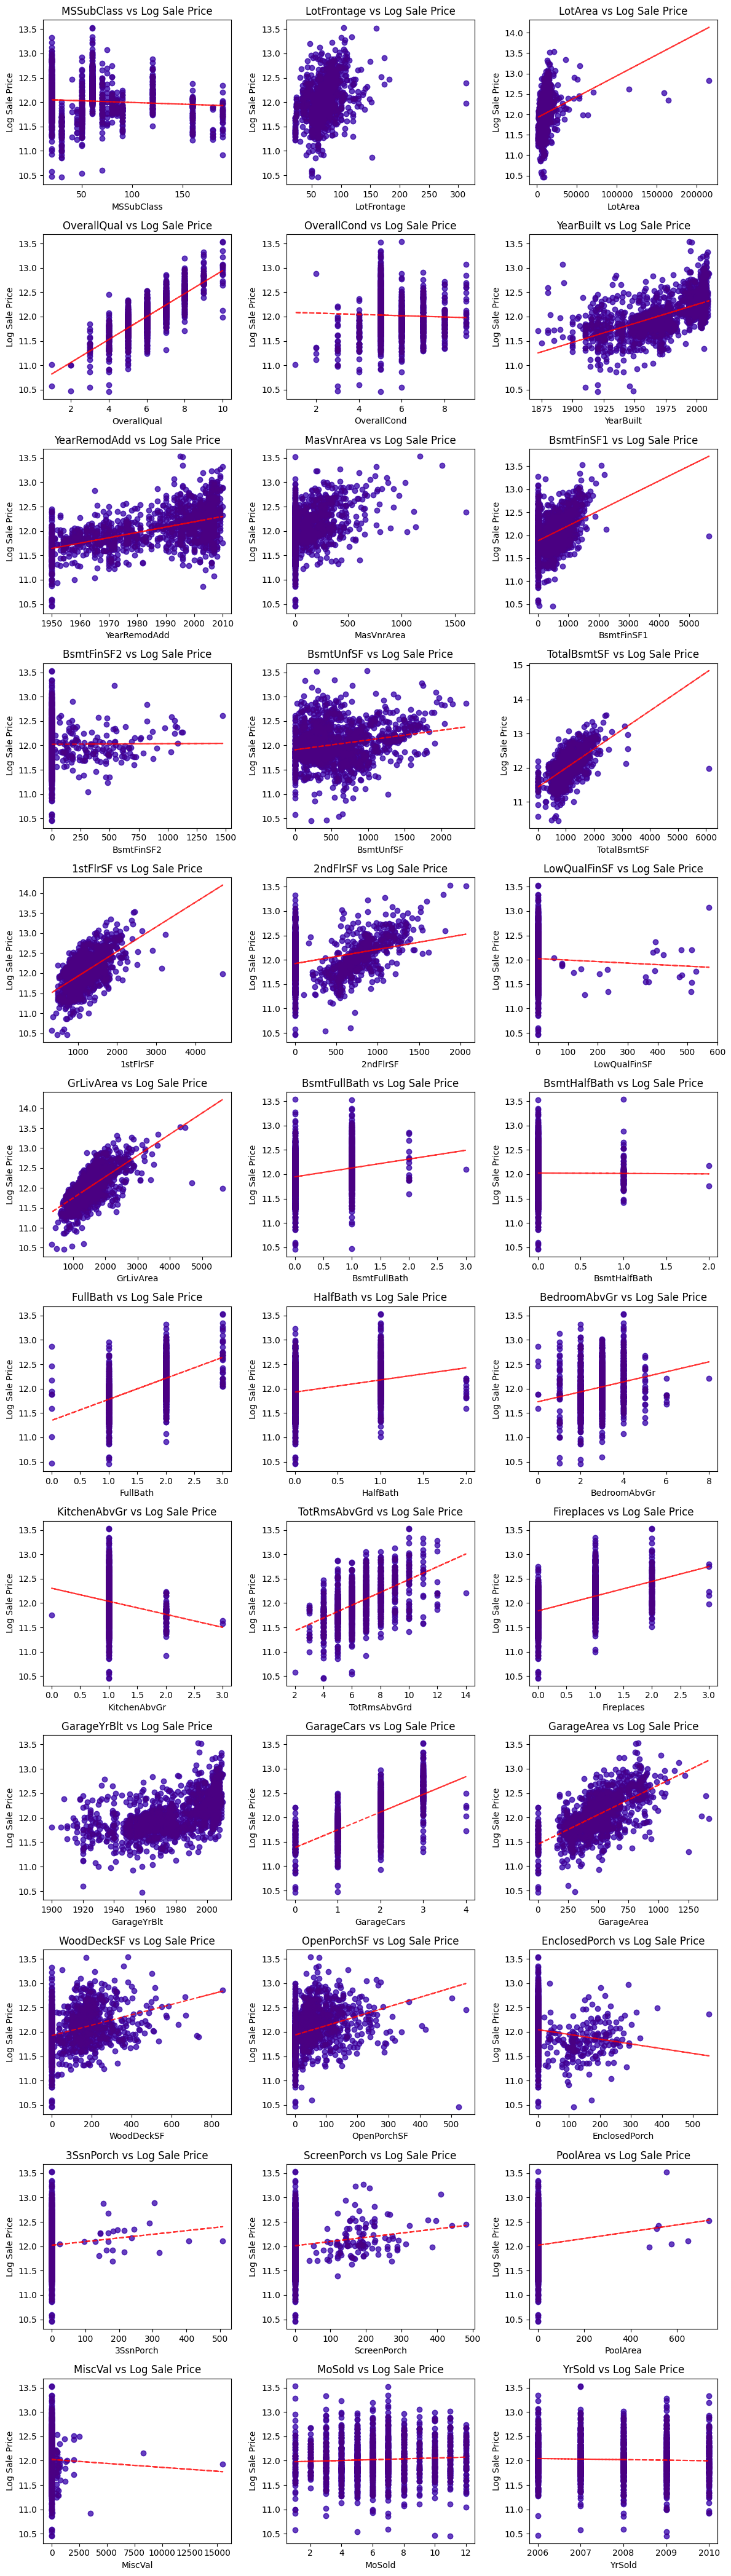

In [ ]:
# Create a figure with subplots for each numerical feature
n_features = len(num_features.columns)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols  # Ceiling division

plt.figure(figsize=(12, 3.5*n_rows))

for idx, col in enumerate(num_features.columns):
    plt.subplot(n_rows, n_cols, idx + 1)

    # Get non-null values only
    # mask = ~num_features[col].isna()
    x = num_features.loc[:, col]
    y = ylog

    # Create scatter plot
    plt.scatter(x, y, alpha=0.5, color='blue')
    # Create scatter plot with a modern color scheme
    plt.scatter(x, y, alpha=0.5, color='#4B0082')  # Deep indigo color that's trendy but still professional
    try:
        # Add regression line using numpy's polyfit
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        plt.plot(x, p(x), "r--", alpha=0.8)
    except:
        # If regression fails, just skip the line
        pass

    plt.xlabel(col)
    plt.ylabel('Log Sale Price')
    plt.title(f'{col} vs Log Sale Price')

plt.tight_layout()
plt.show()

##### boxplot on cat features
###### found potential strong cat features: GarageQual, GarageCond, SaleType, neighborhood (PoolQC- high NA)
###### majority cat features are week predictors, should test whether just throw away?


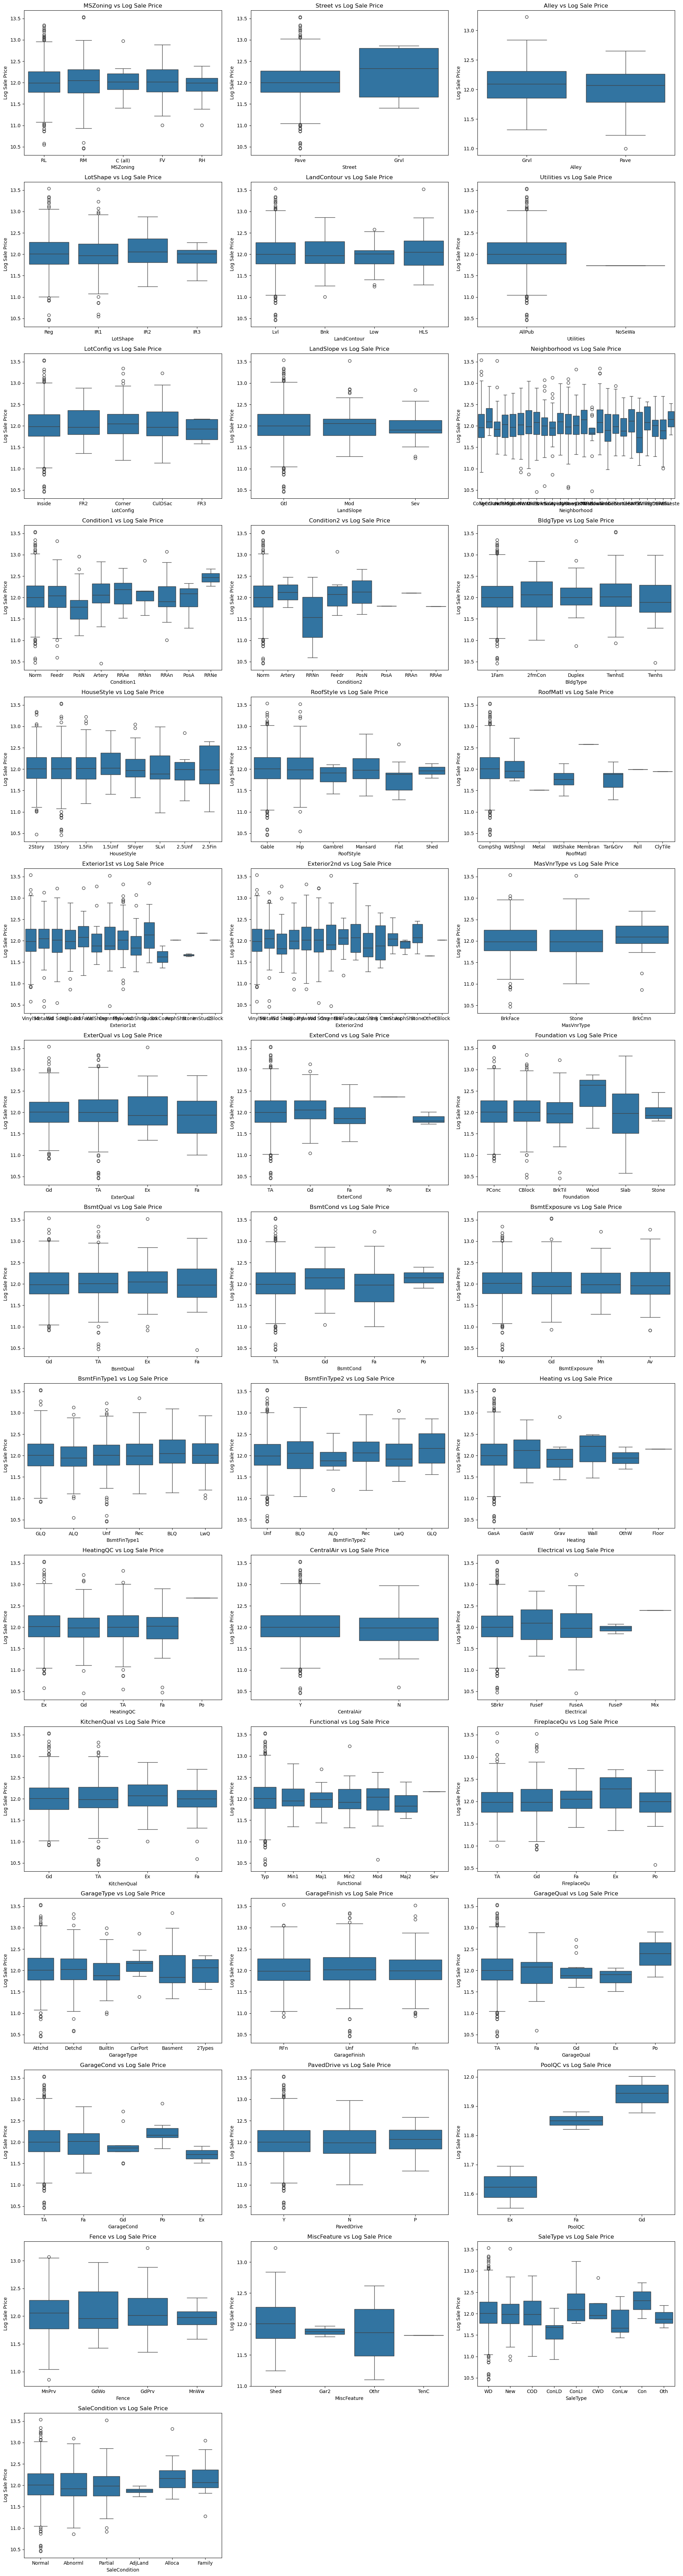

In [ ]:
# Create a figure with subplots for each numerical feature
n_features = len(cat_features.columns)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols  # Ceiling division

plt.figure(figsize=(20, 5*n_rows))

for idx, col in enumerate(cat_features.columns):
    plt.subplot(n_rows, n_cols, idx + 1)

    # Get non-null values only
    # mask = ~num_features[col].isna()
    # x = num_features.loc[mask, col]
    # y = ylog[mask]
    x = cat_features.loc[:, col]
    y = ylog
    dfset = pd.DataFrame({'categorical_feature': x, 'target': y})
    # Create scatter plot
    sns.boxplot(x='categorical_feature', y='target', data=dfset)
    # Create scatter plot with a modern color scheme
    #plt.scatter(x, y, alpha=0.5, color='#4B0082')  # Deep indigo color that's trendy but still professional
    plt.xlabel(col)
    plt.ylabel('Log Sale Price')
    plt.title(f'{col} vs Log Sale Price')

plt.tight_layout()
plt.show()

##### use anova analysis to double check the importance of cat features

### Feature preprocessing  
###### handle NA treatment for both categorical and numerical features; categorical feature treatment: onehot vs. dummy vs. ordinal??, np.log on skewed features?

##### Analyze NA values // X_train_combo


In [ ]:
## Drop 4 features with hgih NA% (PoolQC,MiscFeature,Alley,Fence), they don't show promising views on boxplot analysis
## X_train_combo.drop(['PoolQC','MiscFeature','Alley','Fence'], axis=1, inplace=True)

In [ ]:
## collect column list for na values imputation
catna_cols=colsinfotrain.loc[(colsinfotrain.NAcnt>0) & (colsinfotrain.dtype=='object')].index.tolist()
numna_cols=colsinfotrain.loc[(colsinfotrain.NAcnt>0) & ~(colsinfotrain.dtype=='object')].index.tolist()

In [ ]:
print(catna_cols)
print(numna_cols)

['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'GarageType', 'GarageQual', 'GarageCond', 'GarageFinish', 'BsmtFinType2', 'BsmtExposure', 'BsmtFinType1', 'BsmtQual', 'BsmtCond', 'Electrical']
['LotFrontage', 'GarageYrBlt', 'MasVnrArea']


###### look into 'MasVnrType', NA value is because there is 0 MasVnrArea. Should set 'None' where MasVnrArea is 0

In [ ]:
X_train_combo[['MasVnrType','MasVnrArea']]

,MasVnrType,MasVnrArea
Id,,
1,BrkFace,196.0
2,NaN,0.0
3,BrkFace,162.0
4,NaN,0.0
5,BrkFace,350.0
...,...,...
1456,NaN,0.0
1457,Stone,119.0
1458,NaN,0.0


In [ ]:
X_train_combo.loc[X_train_combo.MasVnrArea==0,'MasVnrType'].unique()

array([nan, 'BrkFace', 'Stone'], dtype=object)

###### look into 'FireplaceQU', NA value is because Fireplace doesn't exist. Should fillna with 'None'

In [ ]:
X_train_combo.loc[X_train_combo.Fireplaces==0,['FireplaceQu']]

,FireplaceQu
Id,
1,NaN
6,NaN
11,NaN
13,NaN
16,NaN
...,...
1453,NaN
1454,NaN
1455,NaN


In [ ]:
X_train_combo.loc[X_train_combo.Fireplaces==0,'FireplaceQu'].unique()

array([nan], dtype=object)

###### look into garage related features ('GarageType', 'GarageQual', 'GarageCond', 'GarageFinish'), NA value is because there is no garage, should set all NA as 'None'

In [ ]:
X_train_combo.loc[X_train_combo.GarageArea==0,['GarageArea','GarageCars','GarageType', 'GarageQual', 'GarageCond', 'GarageFinish']]

,GarageArea,GarageCars,GarageType,GarageQual,GarageCond,GarageFinish
Id,,,,,,
40,0,0,NaN,NaN,NaN,NaN
49,0,0,NaN,NaN,NaN,NaN
79,0,0,NaN,NaN,NaN,NaN
89,0,0,NaN,NaN,NaN,NaN
90,0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
1350,0,0,NaN,NaN,NaN,NaN
1408,0,0,NaN,NaN,NaN,NaN
1450,0,0,NaN,NaN,NaN,NaN


In [ ]:
X_train_combo.loc[X_train_combo.GarageArea==0,['GarageArea','GarageType', 'GarageQual', 'GarageCond', 'GarageFinish']].nunique()

GarageArea      1
GarageType      0
GarageQual      0
GarageCond      0
GarageFinish    0
dtype: int64

###### look into bsmt related features ('BsmtFinType2', 'BsmtExposure', 'BsmtFinType1', 'BsmtQual', 'BsmtCond'), NA value is because there is no basement, should set all NA as 'None'

In [ ]:
X_train_combo[['TotalBsmtSF','BsmtFinType2', 'BsmtExposure', 'BsmtFinType1', 'BsmtQual', 'BsmtCond']]

,TotalBsmtSF,BsmtFinType2,BsmtExposure,BsmtFinType1,BsmtQual,BsmtCond
Id,,,,,,
1,856,Unf,No,GLQ,Gd,TA
2,1262,Unf,Gd,ALQ,Gd,TA
3,920,Unf,Mn,GLQ,Gd,TA
4,756,Unf,No,ALQ,TA,Gd
5,1145,Unf,Av,GLQ,Gd,TA
...,...,...,...,...,...,...
1456,953,Unf,No,Unf,Gd,TA
1457,1542,Rec,No,ALQ,Gd,TA
1458,1152,Unf,No,GLQ,TA,Gd


In [ ]:
X_train_combo.loc[X_train_combo.TotalBsmtSF==0,['BsmtFinType2', 'BsmtExposure', 'BsmtFinType1', 'BsmtQual', 'BsmtCond']].nunique()

BsmtFinType2    0
BsmtExposure    0
BsmtFinType1    0
BsmtQual        0
BsmtCond        0
dtype: int64

###### look into 'Electrical' ?, There is only one NA value, can just apply mode

In [ ]:
X_train_combo.loc[X_train_combo.Electrical.isnull(),['Electrical','Utilities']]

,Electrical,Utilities
Id,,
1380,NaN,AllPub


In [ ]:
X_train_combo['Utilities'].unique()

array(['AllPub', 'NoSeWa'], dtype=object)

###### check 3 numercial feats with NAs ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']: 'LotFrontage' should be turned to 0?

###### numercial feats 'LotFrontage' should be imputed by median grouped by 'BldgType'

In [ ]:
X_train_combo.loc[X_train_combo.LotFrontage.isnull(),['BldgType']].value_counts()

BldgType
1Fam        226
TwnhsE       22
Duplex        5
2fmCon        3
Twnhs         3
Name: count, dtype: int64

In [ ]:
X_train_combo.loc[X_train_combo.BldgType=='TwnhsE',['LotFrontage']].describe()

,LotFrontage
count,92.000000
mean,41.978261
std,11.788408
min,21.000000
25%,34.000000
50%,41.000000
75%,50.000000
max,75.000000


In [ ]:
X_train_combo.loc[X_train_combo.BldgType=='Duplex',['LotFrontage']].describe()

,LotFrontage
count,47.000000
mean,71.595745
std,14.296031
min,35.000000
25%,61.500000
50%,70.000000
75%,80.500000
max,110.000000


In [ ]:
X_train_combo.loc[X_train_combo.BldgType=='1Fam',['LotFrontage']].describe()

,LotFrontage
count,994.000000
mean,74.503018
std,22.514368
min,30.000000
25%,60.000000
50%,71.000000
75%,83.750000
max,313.000000


###### numercial feats 'GarageYrBlt' is because there is no garage, should be inserted with a very old year, should use 1700

In [ ]:
X_train_combo[['YearBuilt']].describe()

,YearBuilt
count,1460.000000
mean,1971.267808
std,30.202904
min,1872.000000
25%,1954.000000
50%,1973.000000
75%,2000.000000
max,2010.000000


###### numercial feats 'MasVnrArea' , should be set as 0

In [ ]:
X_train_combo.loc[X_train_combo.MasVnrArea.isnull(),'MasVnrType']

Id
235     NaN
530     NaN
651     NaN
937     NaN
974     NaN
978     NaN
1244    NaN
1279    NaN
Name: MasVnrType, dtype: object

In [ ]:
X_train_combo['GarageYrBlt']

###### ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']


##### Feature preprocessing starts here: make a copy of X_train_combo as  X_mlb

In [10]:
X_mlb = X_train_combo.copy(deep=True) ##create a data copy
ylog.index=X_mlb.index

##### Feature preprocessing: treat NA values//dataset:X_mlb

In [11]:
## drop 2 categorical features with super high NA%
X_mlb.drop(['PoolQC','MiscFeature'], axis=1, inplace=True)
### fill NA for a bunch of categorical features - fill with 'None'
catna_none = ['Alley','Fence','MasVnrType', 'FireplaceQu', 'GarageType', 'GarageQual', 'GarageCond', 'GarageFinish', 'BsmtFinType2', 'BsmtExposure', 'BsmtFinType1', 'BsmtQual', 'BsmtCond']
X_mlb[catna_none] = X_mlb[catna_none].fillna('None')
### fill na for cat features 'Electrical' - fill with most frequent value
most_frequent_value = X_mlb['Electrical'].mode()[0]
X_mlb['Electrical'] = X_mlb['Electrical'].fillna(most_frequent_value)
### fill NA for 2 numerical features
X_mlb['GarageYrBlt'] = X_mlb['GarageYrBlt'].fillna(1700) ##fill na of garageyrblt with 1700
X_mlb['MasVnrArea'] = X_mlb['MasVnrArea'].fillna(0) ##fill na of MasVnrArea with 0
##fill na of LotFrontage with mean
X_mlb['LotFrontage'] = X_mlb['LotFrontage'].fillna(X_mlb['LotFrontage'].mean())

### Model building & Feature Engineering

##### Model test 1 - RandomForest model & one-hot encoder (onehot generates too many features) -> rmse:0.1503

In [ ]:
# Get list of categorical columns
categorical_columns = X_mlb.select_dtypes(include=['object']).columns

# Update OneHotEncoder to use sparse_output parameter instead of sparse
onehot = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Refit and transform
onehot_encoded = onehot.fit_transform(X_mlb[categorical_columns])
onehot_feature_names = onehot.get_feature_names_out(categorical_columns)

# Convert to DataFrame and join with numeric columns
onehot_df = pd.DataFrame(onehot_encoded, columns=onehot_feature_names, index=X_mlb.index)
X_mlb_onehot = pd.concat([X_mlb.select_dtypes(exclude=['object']), onehot_df], axis=1)

# Split the data into training and validation sets with fixed validation size of 200 samples
X_train, X_valid, y_train, y_valid = train_test_split(X_mlb_onehot, ylog, test_size=200, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_valid.shape}")


Training set shape: (1260, 293)
Validation set shape: (200, 293)


In [ ]:
# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_model.predict(X_valid)

# Evaluate the model using RMSE
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f'Root Mean Squared Error: {rmse:.4f}')

Root Mean Squared Error: 0.1503


In [ ]:
# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_model.predict(X_valid)

# Evaluate the model using RMSE
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f'Root Mean Squared Error: {rmse:.4f}')

Root Mean Squared Error: 0.1486


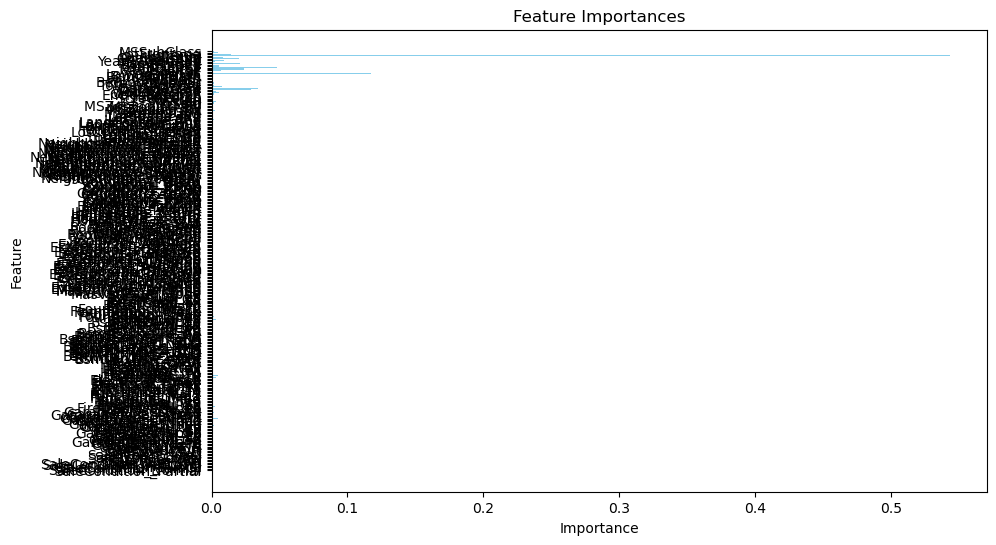

In [ ]:
# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_mlb_onehot.columns

# Create a DataFrame to display feature importances
feature_importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

plt.figure(figsize=(10, 6))
plt.barh(feature_importances_df['Feature'], feature_importances_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.show()

##### Feature Engineering - Use mean encoder to extract meaning out of categorical features (X_train_encoded, X_valid_encoded // ylog)

In [12]:
# Split the data into training and validation sets with fixed validation size of 200 samples
X_train, X_valid, y_train, y_valid = train_test_split(X_mlb, ylog, test_size=200, random_state=42)
from category_encoders import TargetEncoder

# Get list of categorical columns from Xcombo
catcollist = X_mlb.select_dtypes(include=['object']).columns.tolist()

# Apply mean encoding on the training set
mean_encoder = TargetEncoder(cols=catcollist)
X_train_encoded = mean_encoder.fit_transform(X_train, y_train)
# Transform the test set using the fitted mean encoder
X_valid_encoded = mean_encoder.transform(X_valid)

print("Training Set shape: ", X_train_encoded.shape)
print("Test Set shape: ", X_valid_encoded.shape)

Training Set shape:  (1260, 77)
Test Set shape:  (200, 77)


##### Model test 2 - RandomForest model & MeanEncoder -> rmse: 0.1450 (MeanEncoder seems helping model learn well!)

In [ ]:
# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model on the training data
rf_model.fit(X_train_encoded, y_train)

# Make predictions on the test data
y_pred = rf_model.predict(X_valid_encoded)

# Evaluate the model using RMSE
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f'Root Mean Squared Error: {rmse:.4f}')

Root Mean Squared Error: 0.1450


###### Feature importance: Seems only one feature playing an outstanding role to help model to learn

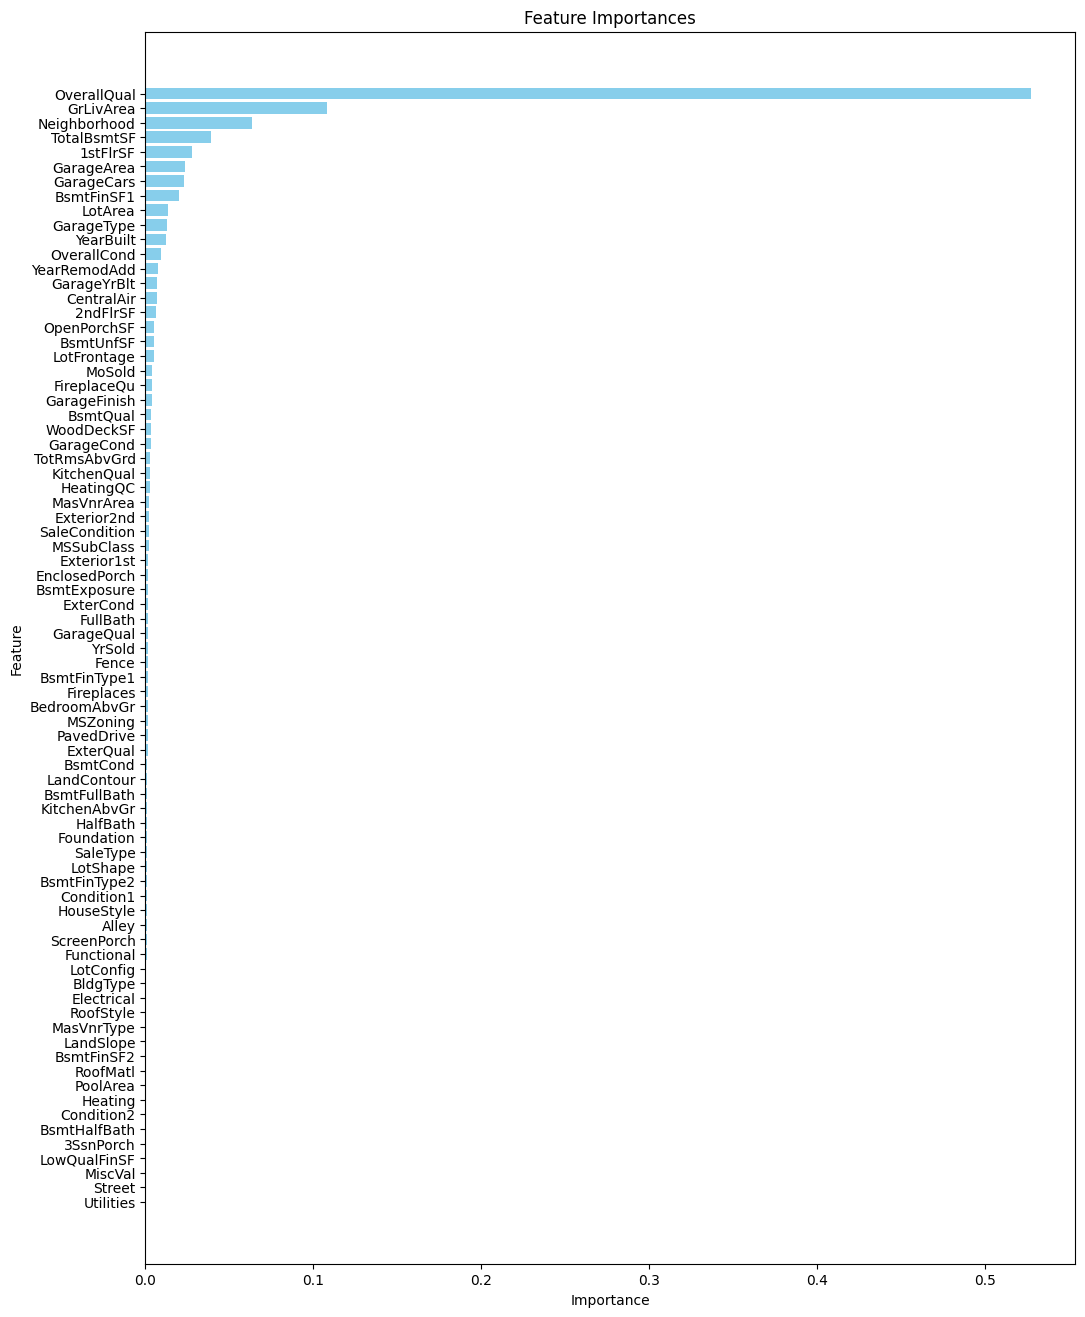

In [ ]:
# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train_encoded.columns

# Create a DataFrame to display feature importances
feature_importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 16))
plt.barh(feature_importances_df['Feature'], feature_importances_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.show()

In [ ]:
feature_importances_df.iloc[:20]

,Feature,Importance
16,OverallQual,0.527353
45,GrLivArea,0.108081
11,Neighborhood,0.063266
37,TotalBsmtSF,0.039208
42,1stFlrSF,0.027474
61,GarageArea,0.023843
60,GarageCars,0.022935
33,BsmtFinSF1,0.019749
3,LotArea,0.013225
57,GarageType,0.012932


##### model test 3 - XGBoost & meanEncoder - rmse 0.1446 (The famous Gradient Boosting Tree model seems not help too much?)

In [ ]:
xgbmodel = XGBRegressor(objective='reg:squarederror',
                        n_estimators=100,
                        learning_rate=0.1,
                        eval_metric='rmse',
                        n_jobs=-1)
# Fit the model with evaluation set
xgbmodel.fit(X_train_encoded, y_train, eval_set=[(X_valid_encoded, y_valid)], verbose=False)

y_pred = xgbmodel.predict(X_valid_encoded)

# Evaluate the model using RMSE
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f'Root Mean Squared Error: {rmse:.4f}')

Root Mean Squared Error: 0.1446


##### Model test 4 - XGBoost w paratuning & meanEncoder - rmse 0.1312 (RandomizedSearchCV helped a lot to find good parameters for Gradient Boosting Tree)

In [ ]:
%%time
## test on parameter tuning for xgboost (keep features)
xgbmodel = XGBRegressor(objective='reg:squarederror',eval_metric='rmse')
# Define the parameter distribution
param_dist = { 'n_estimators': randint(150, 500)
                ,'max_depth': randint(3, 10)  # Randomly pick between 3 and 10
                ,'learning_rate': loguniform(0.005, 0.3)  # Log-uniform distribution between 0.01 and 0.3
                ,'subsample': uniform(0.5, 0.5)  # Randomly pick between 0.6 and 1.0
                ,'colsample_bytree': uniform(0.4, 0.6)  # Randomly pick between 0.6 and 1.0
                ,'gamma': uniform(0, 0.5)  # Randomly pick between 0 and 0.5
                ,'min_child_weight': randint(1, 6)  # Randomly pick between 1 and 5
                #,'reg_alpha': uniform(0, 10)  # Randomly pick between 0 and 10
                #,'reg_lambda': uniform(0, 10)  # Randomly pick between 0 and 10
             }
# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=xgbmodel, param_distributions=param_dist, n_iter=50, cv=3, scoring='neg_mean_squared_error', random_state=42, verbose=2, n_jobs=3)
# Fit the model
random_search.fit(X_train_encoded, y_train, eval_set=[(X_valid_encoded, y_valid)],verbose=False)
# Print the best score
print("Best score: ", np.sqrt((-random_search.best_score_)))
# Print the best parameters
print("Best parameters found: ", random_search.best_params_)
# Use the best model to make predictions
tunedmodel = random_search.best_estimator_
# Evaluate the model using RMSE
y_pred = tunedmodel.predict(X_valid_encoded)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f'Root Mean Squared Error for testset: {rmse:.4f}')

ytrain_pred = tunedmodel.predict(X_train_encoded)
rmse_train = np.sqrt(mean_squared_error(y_train, ytrain_pred))
print(f'Root Mean Squared Error for trainset: {rmse_train:.4f}')

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best score:  0.1284057066203352
Best parameters found:  {'colsample_bytree': 0.916438349953806, 'gamma': 0.0034760652655953517, 'learning_rate': 0.04047212046195181, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 374, 'subsample': 0.5599326836668415}
Root Mean Squared Error for testset: 0.1312
Root Mean Squared Error for trainset: 0.0753
CPU times: user 1.97 s, sys: 164 ms, total: 2.13 s
Wall time: 58 s


###### Feature importance: more features are making significant contribution on help train the model. XGBoost seems to able to utilize more features to train the model!

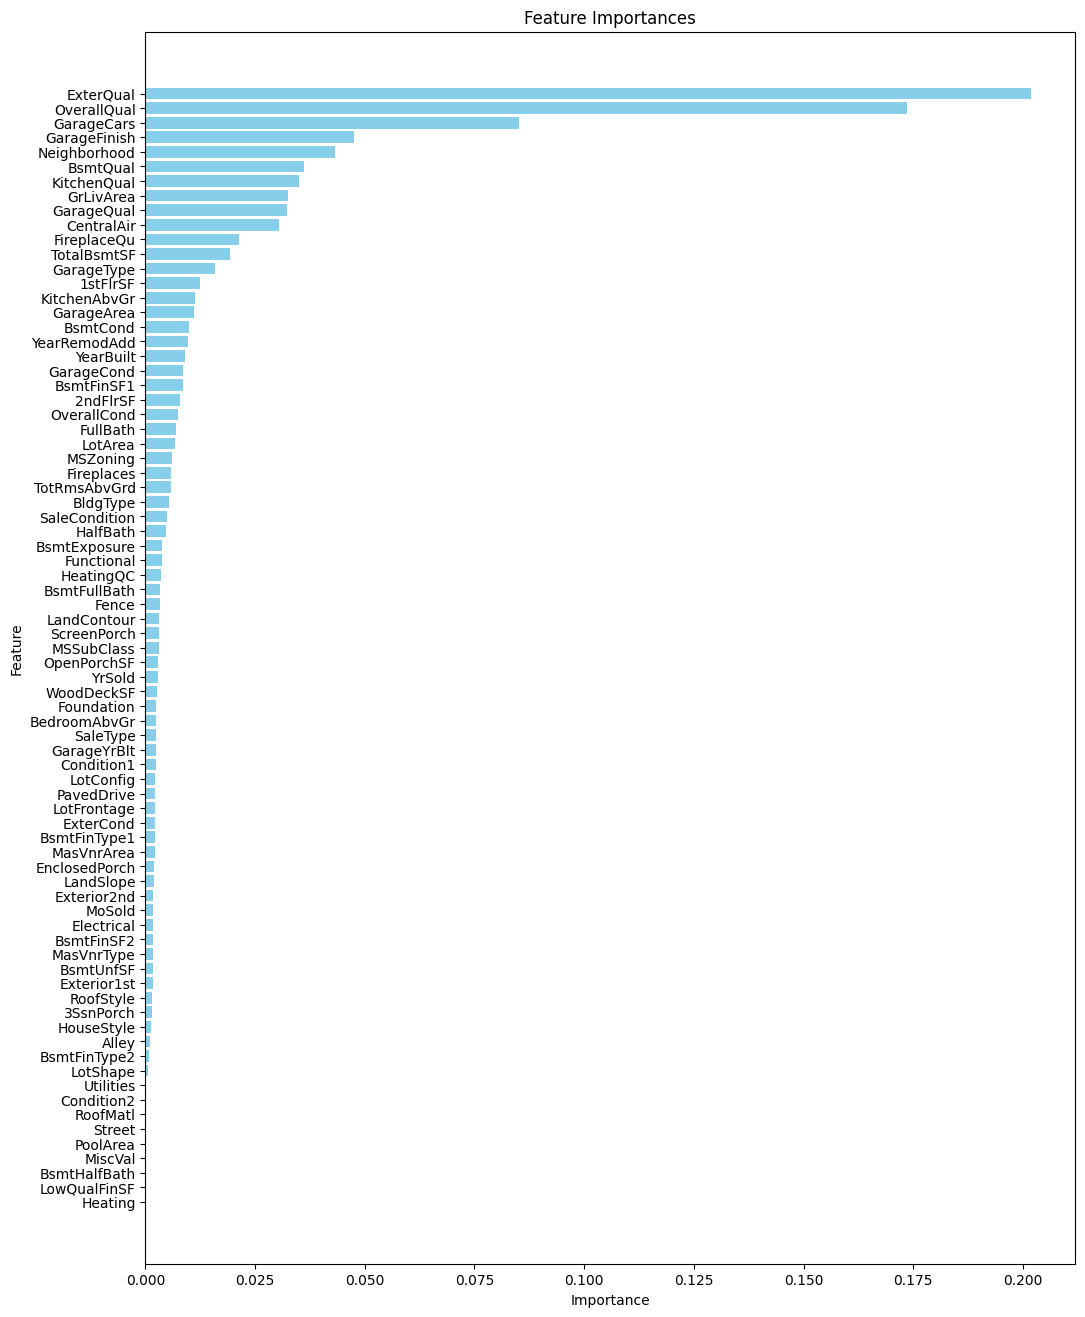

In [ ]:
# Get feature importances
importances = tunedmodel.feature_importances_
feature_names = X_train_encoded.columns

# Create a DataFrame to display feature importances
feature_importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 16))
plt.barh(feature_importances_df['Feature'], feature_importances_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.show()

In [ ]:
feature_importances_df.iloc[:20]

,Feature,Importance
26,ExterQual,0.201879
16,OverallQual,0.173552
60,GarageCars,0.085149
59,GarageFinish,0.047593
11,Neighborhood,0.043223
29,BsmtQual,0.036199
52,KitchenQual,0.035056
45,GrLivArea,0.032431
62,GarageQual,0.032232
40,CentralAir,0.030453


###### test using pipeline: RSME: 0.1315

In [ ]:
import pandas as pd
import numpy as np
from category_encoders import TargetEncoder
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBRegressor

# Custom transformer to handle mean encoding with target
class TargetEncoderWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols=None):
        self.cols = cols
        self.encoder = TargetEncoder(cols=self.cols)

    def fit(self, X, y=None):
        self.encoder.fit(X, y)
        return self

    def transform(self, X, y=None):
        return self.encoder.transform(X)


# Get list of categorical columns
catcollist = X_mlb.select_dtypes(include=['object']).columns.tolist()

# Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X_mlb, ylog, test_size=200, random_state=42)

# Define preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('mean_enc', TargetEncoderWrapper(cols=catcollist), catcollist)
    ],
    remainder='passthrough'
)

# Define the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(objective='reg:squarederror',eval_metric='rmse'))
])

# Define parameter grid for RandomizedSearchCV
param_dist = { 'model__n_estimators': randint(150, 500)
                ,'model__max_depth': randint(3, 10)  # Randomly pick between 3 and 10
                ,'model__learning_rate': loguniform(0.005, 0.3)  # Log-uniform distribution between 0.01 and 0.3
                ,'model__subsample': uniform(0.5, 0.5)  # Randomly pick between 0.6 and 1.0
                ,'model__colsample_bytree': uniform(0.4, 0.6)  # Randomly pick between 0.6 and 1.0
                ,'model__gamma': uniform(0, 0.5)  # Randomly pick between 0 and 0.5
                ,'model__min_child_weight': randint(1, 6)  # Randomly pick between 1 and 5
                #,'reg_alpha': uniform(0, 10)  # Randomly pick between 0 and 10
                #,'reg_lambda': uniform(0, 10)  # Randomly pick between 0 and 10
             }

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=pipeline, param_distributions=param_dist, n_iter=50, cv=3, scoring='neg_mean_squared_error', random_state=42, verbose=2, n_jobs=3)

# Fit RandomizedSearchCV with training data
random_search.fit(X_train, y_train)
# Print the best score
print("Best score: ", np.sqrt((-random_search.best_score_)))
# Print the best parameters
print("Best parameters found: ", random_search.best_params_)

# Get the best model
best_model = random_search.best_estimator_

# Evaluate on validation set
y_pred = best_model.predict(X_valid)
final_rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

print(f'Final RMSE on Validation Set: {final_rmse}')


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best score:  0.12812945397291306
Best parameters found:  {'model__colsample_bytree': 0.916438349953806, 'model__gamma': 0.0034760652655953517, 'model__learning_rate': 0.04047212046195181, 'model__max_depth': 3, 'model__min_child_weight': 5, 'model__n_estimators': 374, 'model__subsample': 0.5599326836668415}
Final RMSE on Validation Set: 0.1314879422959735


##### Model test 5: feature selection RFE (XGBoost w paratuning & meanEncoder) rmse: 0.1270 (X_train_RFE, X_valid_RFE)

In [13]:
%%time
from sklearn.feature_selection import RFE

# Initialize the model
xgbmodel = XGBRegressor(objective='reg:squarederror',
                        n_estimators=100,
                        learning_rate=0.1,
                        eval_metric='rmse',
                        n_jobs=-1)

# Perform RFE
selector = RFE(estimator=xgbmodel, n_features_to_select=60, step=1)
selector = selector.fit(X_train_encoded, y_train)

# Get the selected features
selected_features = X_train_encoded.columns[selector.support_]
X_train_RFE = selector.transform(X_train_encoded)
X_valid_RFE = selector.transform(X_valid_encoded)

CPU times: user 23.3 s, sys: 203 ms, total: 23.5 s
Wall time: 18.7 s


In [14]:
%%time
## test on parameter tuning for xgboost (keep features)
xgbmodel = XGBRegressor(objective='reg:squarederror',eval_metric='rmse')
# Define the parameter distribution
param_dist = { 'n_estimators': randint(150, 500)
                ,'max_depth': randint(3, 10)  # Randomly pick between 3 and 10
                ,'learning_rate': loguniform(0.005, 0.3)  # Log-uniform distribution between 0.01 and 0.3
                ,'subsample': uniform(0.5, 0.5)  # Randomly pick between 0.6 and 1.0
                ,'colsample_bytree': uniform(0.4, 0.6)  # Randomly pick between 0.6 and 1.0
                ,'gamma': uniform(0, 0.5)  # Randomly pick between 0 and 0.5
                ,'min_child_weight': randint(1, 6)  # Randomly pick between 1 and 5
                #,'reg_alpha': uniform(0, 10)  # Randomly pick between 0 and 10
                #,'reg_lambda': uniform(0, 10)  # Randomly pick between 0 and 10
             }
# Initialize RandomizedSearchCV
random_search_rfe = RandomizedSearchCV(estimator=xgbmodel, param_distributions=param_dist, n_iter=50, cv=3, scoring='neg_mean_squared_error', random_state=42, verbose=2, n_jobs=3)
# Fit the model
random_search_rfe.fit(X_train_RFE, y_train, eval_set=[(X_valid_RFE, y_valid)],verbose=False)
# Print the best score
print("Best score: ", np.sqrt((-random_search_rfe.best_score_)))
# Print the best parameters
print("Best parameters found: ", random_search_rfe.best_params_)
# Use the best model to make predictions
tunedmodel_rfe = random_search_rfe.best_estimator_
# Evaluate the model using RMSE
y_pred = tunedmodel_rfe.predict(X_valid_RFE)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f'Root Mean Squared Error for testset: {rmse:.4f}')
ytrain_pred = tunedmodel_rfe.predict(X_train_RFE)
rmse_train = np.sqrt(mean_squared_error(y_train, ytrain_pred))
print(f'Root Mean Squared Error for trainset: {rmse_train:.4f}')

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best score:  0.12653205175949037
Best parameters found:  {'colsample_bytree': np.float64(0.916438349953806), 'gamma': np.float64(0.0034760652655953517), 'learning_rate': np.float64(0.04047212046195181), 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 374, 'subsample': np.float64(0.5599326836668415)}
Root Mean Squared Error for testset: 0.1270
Root Mean Squared Error for trainset: 0.0753
CPU times: user 1.55 s, sys: 200 ms, total: 1.75 s
Wall time: 58.3 s


In [ ]:
###which columns were dropped?
# Get the dropped features
dropped_features = X_train_encoded.columns[~selector.support_]

print("Dropped Features:")
print(dropped_features)


Dropped Features:
Index(['MSSubClass', 'LotFrontage', 'Street', 'Alley', 'LotShape', 'Utilities',
       'Condition2', 'HouseStyle', 'RoofMatl', 'MasVnrType', 'MasVnrArea',
       'Heating', 'Electrical', 'LowQualFinSF', '3SsnPorch', 'PoolArea',
       'MiscVal'],
      dtype='object')


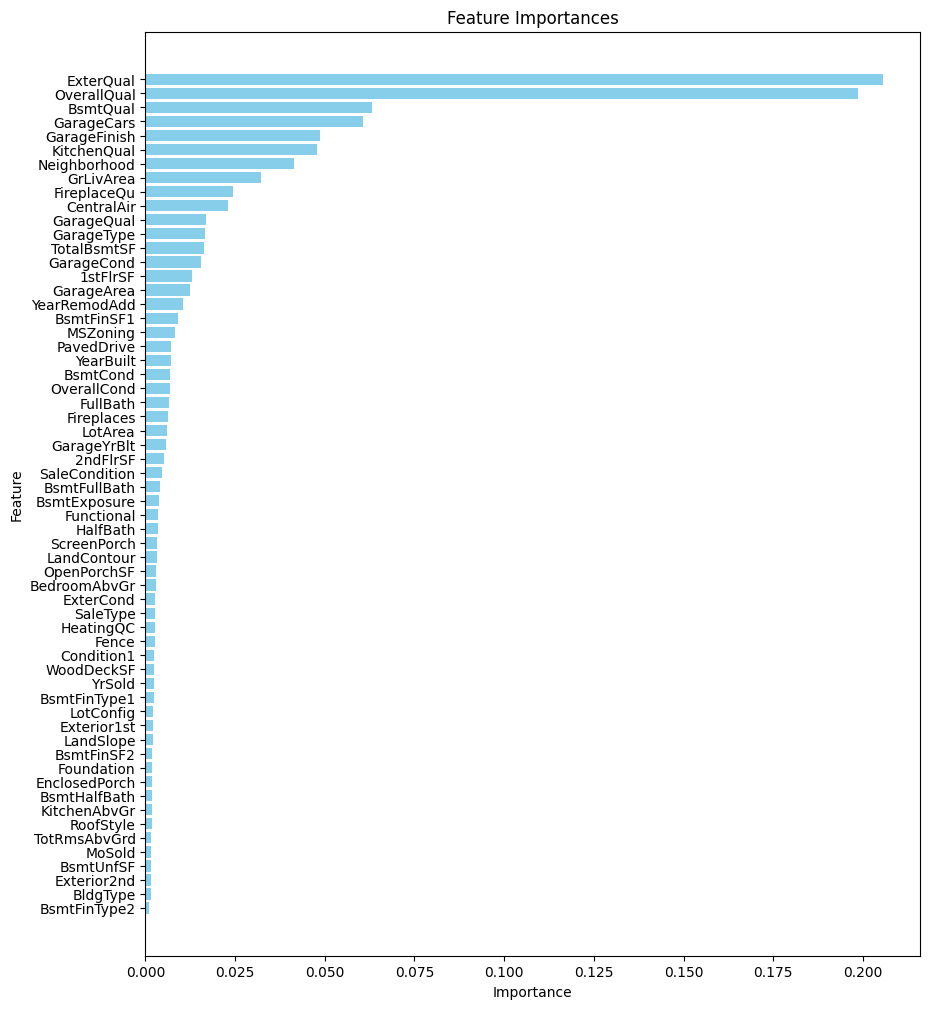

In [ ]:
# Get feature importances
importances = tunedmodel_rfe.feature_importances_
feature_names = selected_features

# Create a DataFrame to display feature importances
feature_importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 12))
plt.barh(feature_importances_df['Feature'], feature_importances_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.show()

### Model inference nference rmse 0.122 - ranked 242 among 3,600 participants

#### Retrain the fine-tuned XGBregressor by using the combined X_train_RFE

In [ ]:
X_train_RFE

array([[1.20839037e+01, 7.07610000e+04, 1.21094630e+01, ...,
        2.00600000e+03, 1.19972403e+01, 1.20092636e+01],
       [1.20839037e+01, 2.18720000e+04, 1.22695371e+01, ...,
        2.00800000e+03, 1.19972403e+01, 1.20092636e+01],
       [1.17071333e+01, 1.06900000e+04, 1.20261102e+01, ...,
        2.00900000e+03, 1.19972403e+01, 1.20092636e+01],
       ...,
       [1.20839037e+01, 8.17200000e+03, 1.20261102e+01, ...,
        2.00600000e+03, 1.19972403e+01, 1.20092636e+01],
       [1.20839037e+01, 7.64200000e+03, 1.20261102e+01, ...,
        2.00700000e+03, 1.19972403e+01, 1.20092636e+01],
       [1.20839037e+01, 3.68400000e+03, 1.20261102e+01, ...,
        2.00900000e+03, 1.19972403e+01, 1.20092636e+01]])

In [ ]:
## combine the train data and valid data
X_train_RFEdf = pd.DataFrame(X_train_RFE, columns=selected_features)
X_valid_RFEdf = pd.DataFrame(X_valid_RFE, columns=selected_features)

X_trainrfe_combo = pd.concat([X_train_RFEdf, X_valid_RFEdf], axis=0)

print(X_trainrfe_combo)

      MSZoning  LotArea  LandContour  LotConfig  LandSlope  Neighborhood  \
0    12.083904  70761.0    12.109463  12.010547  12.104148     12.163862   
1    12.083904  21872.0    12.269537  12.021972  12.023059     12.165863   
2    11.707133  10690.0    12.026110  12.010547  12.023059     11.671803   
3    12.083904   9200.0    12.026110  12.010547  12.023059     12.521820   
4    12.083904   8450.0    12.026110  12.010547  12.023059     12.179004   
..         ...      ...          ...        ...        ...           ...   
195  12.083904   7800.0    11.813764  12.010547  12.104148     11.708049   
196  12.246084   3316.0    12.026110  12.010547  12.023059     12.300876   
197  11.886886   8500.0    12.026110  12.010547  12.023059     11.671803   
198  12.246084   2645.0    12.026110  12.010547  12.023059     12.300876   
199  12.083904   7681.0    12.026110  12.021972  12.023059     12.196986   

     Condition1   BldgType  OverallQual  OverallCond  ...  PavedDrive  \
0     12.04475

In [ ]:
## combine the train data and valid data
y_train_RFE = pd.DataFrame(y_train)
y_valid_RFE = pd.DataFrame(y_valid)
y_trainrfe_combo = pd.concat([y_train_RFE, y_valid_RFE], axis=0, ignore_index=True)
y_trainrfe_combo

,SalePrice
0,12.542545
1,12.072541
2,11.898188
3,12.660328
4,12.128111
...,...
1455,12.323856
1456,12.190959
1457,10.596635
1458,12.058153


In [ ]:
%%time
### retrain the model based on the whole dataset

# Retrieve the best parameters from RandomizedSearchCV
best_params = random_search_rfe.best_params_

# Add additional parameters
additional_params = {
    'objective':'reg:squarederror',
    'eval_metric':'rmse'
}

# Update the best parameters with the new ones
best_params.update(additional_params)

# Create a new model with the updated parameters
model_inference = XGBRegressor(**best_params)

# Train the final model on the combined dataset (or any dataset you choose)
model_inference.fit(X_trainrfe_combo, y_trainrfe_combo)

ytrain_pred_rfe = model_inference.predict(X_trainrfe_combo)
rmse_train = np.sqrt(mean_squared_error(y_trainrfe_combo, ytrain_pred_rfe))
print(f'Root Mean Squared Error for trainset: {rmse_train:.4f}')

Root Mean Squared Error for trainset: 0.0794
CPU times: user 2.21 s, sys: 6.07 ms, total: 2.22 s
Wall time: 2.17 s


#### Implement data cleaning and feature engi for X_test

In [ ]:
print(X_test.shape)
X_test.head()

(1459, 79)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [ ]:
## drop 2 categorical features with super high NA%
X_test2 = X_test.copy(deep=True)
X_test2.drop(['PoolQC','MiscFeature'], axis=1, inplace=True)
### fill NA for a bunch of categorical features - fill with 'None'
catna_none = ['Alley','Fence','MasVnrType', 'FireplaceQu', 'GarageType', 'GarageQual', 'GarageCond', 'GarageFinish', 'BsmtFinType2', 'BsmtExposure', 'BsmtFinType1', 'BsmtQual', 'BsmtCond']
X_test2[catna_none] = X_test2[catna_none].fillna('None')
### fill na for cat features 'Electrical' - fill with most frequent value
most_frequent_value = X_test2['Electrical'].mode()[0]
X_test2['Electrical'] = X_test2['Electrical'].fillna(most_frequent_value)
### fill NA for 2 numerical features
X_test2['GarageYrBlt'] = X_test2['GarageYrBlt'].fillna(1700) ##fill na of garageyrblt with 1700
X_test2['MasVnrArea'] = X_test2['MasVnrArea'].fillna(0) ##fill na of MasVnrArea with 0
##fill na of LotFrontage with mean
X_test2['LotFrontage'] = X_test2['LotFrontage'].fillna(X_test2['LotFrontage'].mean())

X_test_encoded = mean_encoder.transform(X_test2)

print("Training Set shape: ", X_train_encoded.shape)
print("Valid Set shape: ", X_valid_encoded.shape)
print("Test Set shape: ", X_test_encoded.shape)


Training Set shape:  (1260, 77)
Valid Set shape:  (200, 77)
Test Set shape:  (1459, 77)


In [ ]:
X_test_RFE = selector.transform(X_test_encoded)
print(X_test_RFE.shape)

(1459, 60)



#### Implement inference - obtained inference rmse 0.122 - ranked 242 among 3,600 participants

In [ ]:
y_pred_test = model_inference.predict(X_test_RFE)
testpred = np.exp(y_pred_test)
print(np.mean(testpred))
print(testpred)

test_id=X_test.index.tolist()
def submit_method(test_id, y_prediction):
    sub = pd.DataFrame()
    sub['Id'] = test_id
    sub['SalePrice'] = y_prediction
    print(sub.shape)
    return sub

subcsv=submit_method(test_id, testpred)

subcsv.to_csv('submission20250301v2.csv', index=False)

177583.69
[126646.5  160282.86 183504.62 ... 160738.4  115585.23 196617.1 ]


In [ ]:
test_id=X_test.index.tolist()
def submit_method(test_id, y_prediction):
    sub = pd.DataFrame()
    sub['Id'] = test_id
    sub['SalePrice'] = y_prediction
    print(sub.shape)
    return sub

subcsv=submit_method(test_id, testpred)

subcsv.to_csv('submission20250301v2.csv', index=False)

(1459, 2)


### Feature Engineering
##### Try to create new features through combining existing features and create more powerful ones. But this doesn't really help XGBoost regressor.
##### The learning here is that, for XGBoost, you'd better let it handle feature engineering by itself instead of manually creating new ones. XGBoost naturally can handle feature selection and feature interaction by using its algorthm.

In [ ]:
## make a copy of X_mlb to handle feature engineering
X_mlbfe = X_mlb.copy(deep=True)

#### Feature Engineering 1 - Create new numerical feats (SF features, room counts, porch size etc) - rmse: 0.1318: Didn't get better performance! Just wondering if there are some redudant/correlated features, should have better performance if conducting feature selection

In [ ]:
### good above grade living area // new formula
X_mlbfe['GrLivArea_good'] = X_mlbfe['GrLivArea']-X_mlbfe['LowQualFinSF']
### good above grade living area%
X_mlbfe['GrLivArea_good%'] = X_mlbfe['GrLivArea_good']/X_mlbfe['GrLivArea']

### total liv area (bsmt area + grlivarea )
X_mlbfe['LivArea_total'] = X_mlbfe['GrLivArea']+X_mlbfe['TotalBsmtSF']
### total liv area good (finished bsmt area + grlivarea_good)
X_mlbfe['LivArea_good'] = X_mlbfe['GrLivArea_good']+X_mlbfe['BsmtFinSF1']+X_mlbfe['BsmtFinSF1']
### total liv area good %
X_mlbfe['LivArea_good%'] = X_mlbfe['LivArea_good']/X_mlbfe['LivArea_total']

## TotalOutdoorArea
X_mlbfe['TotalOutdoorArea'] = X_mlbfe['WoodDeckSF'] + X_mlbfe['OpenPorchSF'] + X_mlbfe['EnclosedPorch'] + X_mlbfe['3SsnPorch'] + X_mlbfe['ScreenPorch']

## calculate SQFT per room // new formula
X_mlbfe["SqFtPerRoom"] = X_mlbfe["GrLivArea"] / (X_mlbfe["TotRmsAbvGrd"])

## add count of bathrooms
X_mlbfe['Total_Bathrooms'] = (X_mlbfe['FullBath'] + (0.5 * X_mlbfe['HalfBath']) +X_mlbfe['BsmtFullBath'] + (0.5 * X_mlbfe['BsmtHalfBath']))
## enhance the feature of house condiction
#X_mlbfe['Total_Home_Quality'] = X_mlbfe['OverallQual'] + X_mlbfe['OverallCond']
### transform year features
X_mlbfe["HouseAge"] = pd.to_numeric(X_mlbfe["YrSold"])-pd.to_numeric(X_mlbfe["YearBuilt"])
X_mlbfe["RenovateAge"] = pd.to_numeric(X_mlbfe["YrSold"]) - pd.to_numeric(X_mlbfe["YearRemodAdd"])

X_mlbfe['Total_Home_Quality'] = X_mlbfe['OverallQual'] + X_mlbfe['OverallCond']

# Split the data into training and validation sets with fixed validation size of 200 samples
Xfe_train, Xfe_valid, y_train, y_valid = train_test_split(X_mlbfe, ylog, test_size=200, random_state=42)

#from category_encoders import TargetEncoder
catcollist = X_mlbfe.select_dtypes(include=['object']).columns.tolist()
# Apply mean encoding on the training set
mean_encoder = TargetEncoder(cols=catcollist)
Xfe_train_encoded = mean_encoder.fit_transform(Xfe_train, y_train)
# Transform the test set using the fitted mean encoder
Xfe_valid_encoded = mean_encoder.transform(Xfe_valid)

# Now X_train_encoded and X_test_encoded are ready for model training and evaluation
print("Training Set shape:", Xfe_train_encoded.shape)
print("Test Set shape:", Xfe_valid_encoded.shape)

Training Set shape: (1260, 89)
Test Set shape: (200, 89)


In [ ]:
%%time
## test on parameter tuning for xgboost (keep features)
xgbmodel = XGBRegressor(objective='reg:squarederror',eval_metric='rmse')
# Define the parameter distribution
param_dist = { 'n_estimators': randint(150, 500)
                ,'max_depth': randint(3, 10)  # Randomly pick between 3 and 10
                ,'learning_rate': loguniform(0.005, 0.3)  # Log-uniform distribution between 0.01 and 0.3
                ,'subsample': uniform(0.5, 0.5)  # Randomly pick between 0.6 and 1.0
                ,'colsample_bytree': uniform(0.4, 0.6)  # Randomly pick between 0.6 and 1.0
                ,'gamma': uniform(0, 0.5)  # Randomly pick between 0 and 0.5
                ,'min_child_weight': randint(1, 6)  # Randomly pick between 1 and 5
                #,'reg_alpha': uniform(0, 10)  # Randomly pick between 0 and 10
                #,'reg_lambda': uniform(0, 10)  # Randomly pick between 0 and 10
             }
# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=xgbmodel, param_distributions=param_dist, n_iter=50, cv=3, scoring='neg_mean_squared_error', random_state=42, verbose=2, n_jobs=3)
# Fit the model
random_search.fit(Xfe_train_encoded, y_train, eval_set=[(Xfe_valid_encoded, y_valid)],verbose=False)
# Print the best score
print("Best score: ", np.sqrt((-random_search.best_score_)))
# Print the best parameters
print("Best parameters found: ", random_search.best_params_)
# Use the best model to make predictions
tunedmodel = random_search.best_estimator_
# Evaluate the model using RMSE
y_pred = tunedmodel.predict(Xfe_valid_encoded)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f'Root Mean Squared Error for testset: {rmse:.4f}')

ytrain_pred = tunedmodel.predict(Xfe_train_encoded)
rmse_train = np.sqrt(mean_squared_error(y_train, ytrain_pred))
print(f'Root Mean Squared Error for trainset: {rmse_train:.4f}')

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best score:  0.12663244539456384
Best parameters found:  {'colsample_bytree': 0.4991601634378015, 'gamma': 0.007818203370596966, 'learning_rate': 0.028303612950642508, 'max_depth': 3, 'min_child_weight': 4, 'n_estimators': 285, 'subsample': 0.5027610585618012}
Root Mean Squared Error for testset: 0.1318
Root Mean Squared Error for trainset: 0.0890
CPU times: user 3.35 s, sys: 365 ms, total: 3.71 s
Wall time: 1min 59s


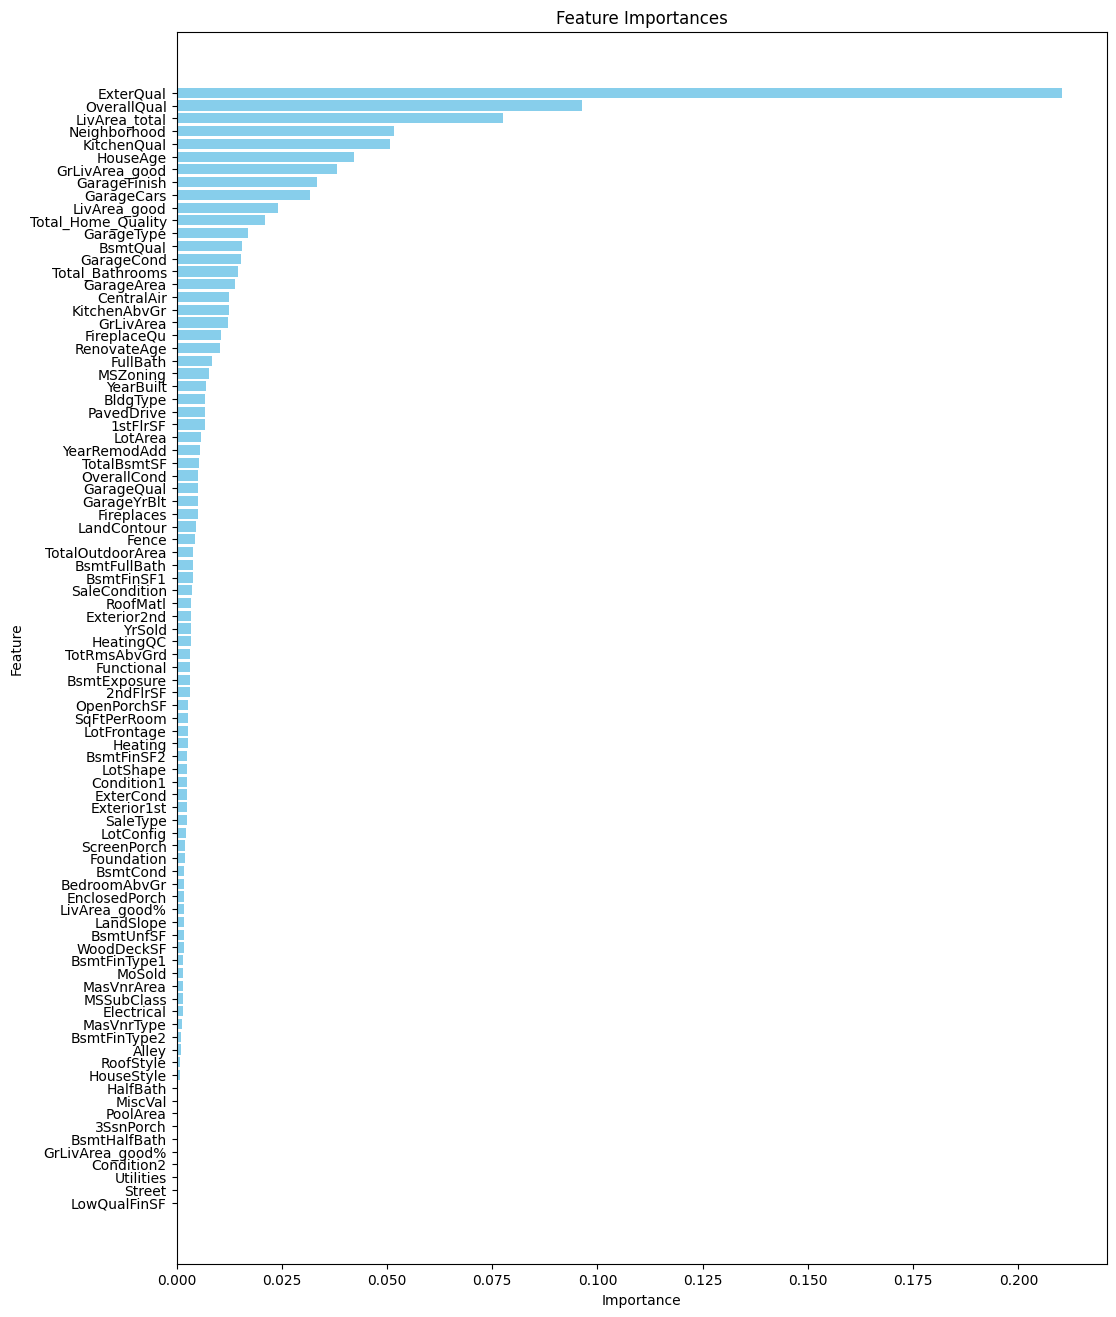

In [ ]:
# Get feature importances
importances = tunedmodel.feature_importances_
feature_names = X_train_encoded.columns

# Create a DataFrame to display feature importances
feature_importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 16))
plt.barh(feature_importances_df['Feature'], feature_importances_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.show()

#### Feature Engineering 2 - try to overcome overfitting: mannually cut redundant features - rmse: 0.1331; the model performance gets worse, so need to figure out a better way of feature selection

In [ ]:
## make a copy of the data
X_mlbfe12 = X_mlb.copy(deep=True)

X_mlbfe12.drop(['GrLivArea_good','LowQualFinSF','LivArea_good','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
                  'FullBath','HalfBath','BsmtFullBath','BsmtHalfBath','OverallCond','YearBuilt','YearRemodAdd','YrSold','MoSold'], axis=1, inplace=True)

# Split the data into training and validation sets with fixed validation size of 200 samples
X_train, X_valid, y_train, y_valid = train_test_split(X_mlbfe12, ylog, test_size=200, random_state=42)

#from category_encoders import TargetEncoder
catcollist = X_mlbfe12.select_dtypes(include=['object']).columns.tolist()
# Apply mean encoding on the training set
mean_encoder = TargetEncoder(cols=catcollist)
X_train_encoded = mean_encoder.fit_transform(X_train, y_train)
# Transform the test set using the fitted mean encoder
X_valid_encoded = mean_encoder.transform(X_valid)

# Now X_train_encoded and X_test_encoded are ready for model training and evaluation
print("Training Set shape:", X_train_encoded.shape)
print("Test Set shape:", X_valid_encoded.shape)

Training Set shape: (1260, 68)
Test Set shape: (200, 68)


In [ ]:
%%time
## 2 more feats
## test on parameter tuning for xgboost (keep features)
xgbmodel = XGBRegressor(objective='reg:squarederror',eval_metric='rmse')
# Define the parameter distribution
param_dist = { 'n_estimators': randint(150, 500)
                ,'max_depth': randint(3, 10)  # Randomly pick between 3 and 10
                ,'learning_rate': loguniform(0.005, 0.3)  # Log-uniform distribution between 0.01 and 0.3
                ,'subsample': uniform(0.5, 0.5)  # Randomly pick between 0.6 and 1.0
                ,'colsample_bytree': uniform(0.4, 0.6)  # Randomly pick between 0.6 and 1.0
                ,'gamma': uniform(0, 0.5)  # Randomly pick between 0 and 0.5
                ,'min_child_weight': randint(1, 6)  # Randomly pick between 1 and 5
                #,'reg_alpha': uniform(0, 10)  # Randomly pick between 0 and 10
                #,'reg_lambda': uniform(0, 10)  # Randomly pick between 0 and 10
             }
# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=xgbmodel, param_distributions=param_dist, n_iter=50, cv=3, scoring='neg_mean_squared_error', random_state=42, verbose=2, n_jobs=3)
# Fit the model
random_search.fit(X_train_encoded, y_train, eval_set=[(X_valid_encoded, y_valid)],verbose=False)
# Print the best score
print("Best score: ", np.sqrt((-random_search.best_score_)))
# Print the best parameters
print("Best parameters found: ", random_search.best_params_)
# Use the best model to make predictions
tunedmodel = random_search.best_estimator_
# Evaluate the model using RMSE
y_pred = tunedmodel.predict(X_valid_encoded)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f'Root Mean Squared Error for testset: {rmse:.4f}')

ytrain_pred = tunedmodel.predict(X_train_encoded)
rmse_train = np.sqrt(mean_squared_error(y_train, ytrain_pred))
print(f'Root Mean Squared Error for trainset: {rmse_train:.4f}')

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best score:  0.12628409293524456
Best parameters found:  {'colsample_bytree': 0.5437371344001835, 'gamma': 0.07244743604561155, 'learning_rate': 0.037092921636491055, 'max_depth': 8, 'min_child_weight': 4, 'n_estimators': 352, 'subsample': 0.6848272280307022}
Root Mean Squared Error for testset: 0.1331
Root Mean Squared Error for trainset: 0.0753
CPU times: user 1.85 s, sys: 123 ms, total: 1.98 s
Wall time: 45 s


#### Feature Engineering 3 - Try RFE feature selection - RMSE: 0.1293; The performance didn't show improvements! Why? I guess XGBoost library natually can handle a lot of feature selection and feature interactions, which already extract a lot of meaningful info out of the features.

In [ ]:
##               70: 0.1321; 65:0.1288; 62:0.1335; 60:0.1280; 55:0.1307
## 2 more feats: 70: 0.1282; 68:0.1261; 65:0.1292; 63:0.1306; 60:0.1291;
## last tests:   70: 0.1317; 68:0.1295; 65:0.1307; 63:0.1; 60:0.1;
## new test: 75:0.1306; 73:0.1299; 70: 0.1309; 68:0.1293

In [ ]:
%%time
## Implement RFE feature selection
from sklearn.feature_selection import RFE

# Initialize the model
xgbmodel = XGBRegressor(objective='reg:squarederror',
                        n_estimators=100,
                        learning_rate=0.1,
                        eval_metric='rmse',
                        n_jobs=-1)

# Perform RFE
selector = RFE(estimator=xgbmodel, n_features_to_select=68, step=1)
selector = selector.fit(Xfe_train_encoded, y_train)

# Get the selected features
selected_features = Xfe_train.columns[selector.support_]
Xfe_train_RFE = selector.transform(Xfe_train_encoded)
Xfe_valid_RFE = selector.transform(Xfe_valid_encoded)

print(f'RFE train set shape is {Xfe_train_RFE.shape}')
print(f'RFE valid set shape is {Xfe_valid_RFE.shape}')

RFE train set shape is (1260, 68)
RFE valid set shape is (200, 68)
CPU times: user 46.5 s, sys: 193 ms, total: 46.6 s
Wall time: 34.4 s


In [ ]:
%%time
## test on parameter tuning for xgboost (keep features)
xgbmodel = XGBRegressor(objective='reg:squarederror',eval_metric='rmse')
# Define the parameter distribution
param_dist = { 'n_estimators': randint(150, 500)
                ,'max_depth': randint(3, 10)  # Randomly pick between 3 and 10
                ,'learning_rate': loguniform(0.005, 0.3)  # Log-uniform distribution between 0.01 and 0.3
                ,'subsample': uniform(0.5, 0.5)  # Randomly pick between 0.6 and 1.0
                ,'colsample_bytree': uniform(0.4, 0.6)  # Randomly pick between 0.6 and 1.0
                ,'gamma': uniform(0, 0.5)  # Randomly pick between 0 and 0.5
                ,'min_child_weight': randint(1, 6)  # Randomly pick between 1 and 5
                #,'reg_alpha': uniform(0, 10)  # Randomly pick between 0 and 10
                #,'reg_lambda': uniform(0, 10)  # Randomly pick between 0 and 10
             }
# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=xgbmodel, param_distributions=param_dist, n_iter=50, cv=3, scoring='neg_mean_squared_error', random_state=42, verbose=2, n_jobs=3)
# Fit the model
random_search.fit(Xfe_train_RFE, y_train, eval_set=[(Xfe_valid_RFE, y_valid)],verbose=False)
# Print the best score
print("Best score: ", np.sqrt((-random_search.best_score_)))
# Print the best parameters
print("Best parameters found: ", random_search.best_params_)
# Use the best model to make predictions
tunedmodel = random_search.best_estimator_
# Evaluate the model using RMSE
y_pred = tunedmodel.predict(Xfe_valid_RFE)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f'Root Mean Squared Error for testset: {rmse:.4f}')

ytrain_pred = tunedmodel.predict(Xfe_train_RFE)
rmse_train = np.sqrt(mean_squared_error(y_train, ytrain_pred))
print(f'Root Mean Squared Error for trainset: {rmse_train:.4f}')

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best score:  0.1274051303551732
Best parameters found:  {'colsample_bytree': 0.4991601634378015, 'gamma': 0.007818203370596966, 'learning_rate': 0.028303612950642508, 'max_depth': 3, 'min_child_weight': 4, 'n_estimators': 285, 'subsample': 0.5027610585618012}
Root Mean Squared Error for testset: 0.1293
Root Mean Squared Error for trainset: 0.0897
CPU times: user 1.75 s, sys: 159 ms, total: 1.91 s
Wall time: 1min 9s


### Deep Neutral Network
#### DNN is famous for creating new features and handling feature selection, let's give it a try!

#### Some preparation - import library, build data pipeline, curate testdata

In [15]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 kB 18.7 MB/s eta 0:00:00


In [16]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import optuna

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
# ====== Data Pipeline ======

batch_size = 32
train_features_np = X_train_encoded.values
valid_features_np = X_valid_encoded.values

# Normalize features using StandardScaler
scaler = StandardScaler()
train_features_np = scaler.fit_transform(train_features_np)
valid_features_np = scaler.transform(valid_features_np)

## Normalize prediction target
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_valid_scaled = target_scaler.transform(y_valid.values.reshape(-1, 1))

# Convert NumPy arrays to PyTorch tensors after normalization
train_features = torch.tensor(train_features_np, dtype=torch.float32).to(device)
valid_features = torch.tensor(valid_features_np, dtype=torch.float32).to(device)
train_labels = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1).to(device)
valid_labels = torch.tensor(y_valid_scaled, dtype=torch.float32).view(-1, 1).to(device)

# Create dataloaders
# batch_size = 16
train_dataset = TensorDataset(train_features, train_labels)
valid_dataset = TensorDataset(valid_features, valid_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

### DNN complex tuning - add LR

#### Model tuning and training

In [19]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import optuna

# ====== Setup: Device and Fixed Hyperparameters ======
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Fixed hyperparameters (for aspects not tuned by Optuna)
# batch_size = 32         # Batch size
dropout_rate = 0.2      # Dropout rate in the MLP
max_epochs = 100        # Maximum number of epochs per trial
patience = 10           # Patience for early stopping (used in scheduler)
criterion = nn.MSELoss()  # Mean Squared Error for regression

# ====== Model Definition Functions ======
def define_model(trial):
    """Define the MLP architecture for a given Optuna trial.
       Tuning both number of hidden layers and neurons per layer."""
    n_layers = trial.suggest_int("n_layers", 2, 4)
    layers = []
    input_dim = X_train.shape[1]  # number of features
    for i in range(n_layers):
        units = trial.suggest_int(f"n_units_l{i}", 64, 256)
        layers.append(nn.Linear(input_dim, units))
        layers.append(nn.ReLU())
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        input_dim = units
    layers.append(nn.Linear(input_dim, 1))  # Output layer for regression
    model = nn.Sequential(*layers)
    return model

def build_model_from_config(config):
    """Rebuild a model from a configuration dictionary (e.g., best found params)."""
    n_layers = config["n_layers"]
    layers = []
    input_dim = X_train.shape[1]
    for i in range(n_layers):
        units = config[f"n_units_l{i}"]
        layers.append(nn.Linear(input_dim, units))
        layers.append(nn.ReLU())
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        input_dim = units
    layers.append(nn.Linear(input_dim, 1))
    model = nn.Sequential(*layers)
    return model

# ====== Training Function with ReduceLROnPlateau ======
def train_model(model, lr):
    """
    Train the model for up to max_epochs with early stopping using
    ReduceLROnPlateau for dynamic learning rate adjustment.
    Returns the best validation loss and the best model state dict.
    """
    # Create optimizer with the tuned learning rate
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Setup ReduceLROnPlateau scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=patience, factor=0.5, min_lr=1e-6, verbose=True
    )

    best_val_loss = float('inf')
    best_state_dict = None

    for epoch in range(1, max_epochs + 1):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

        # Evaluate on validation set
        model.eval()
        val_loss_sum = 0.0
        total_samples = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch)
                val_loss_sum += F.mse_loss(preds, y_batch, reduction='sum').item()
                total_samples += len(X_batch)
        val_loss = val_loss_sum / total_samples

        # Update best validation loss and state dict if improved
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = {k: v.cpu() for k, v in model.state_dict().items()}

        # Step the scheduler using the validation loss
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        if epoch % 100 == 0:
          print(f"Epoch {epoch}: val_loss={val_loss:.6f}, lr={current_lr:.1e}")

        # Early stopping: if lr has reached the minimum threshold, stop training
        if current_lr <= scheduler.min_lrs[0]:
            print(f"Learning rate reached minimum threshold ({scheduler.min_lrs[0]}). Early stopping.")
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
    return best_val_loss, best_state_dict

# ====== Global Tracking for Best Model ======
best_global_model_state = None
best_global_val_loss = float('inf')
best_global_params = None

# ====== Optuna Objective Function ======
def objective(trial):
    global best_global_model_state, best_global_val_loss, best_global_params

    # Tune the initial learning rate as well as the network architecture
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    model = define_model(trial).to(device)
    val_loss, best_state = train_model(model, lr)

    # Update global best if current trial is better
    if val_loss < best_global_val_loss:
        best_global_val_loss = val_loss
        best_global_params = trial.params  # includes architecture & learning rate
        best_global_model_state = best_state
        torch.save(best_global_model_state, "best_dnnmodel2_statedict.pth")
        print(f"*** New best model found! Val MSE={val_loss:.6f}, Params={best_global_params}")
    return val_loss  # Optuna minimizes this

# ====== Run Optuna Study ======
study = optuna.create_study(direction="minimize")
print("Starting hyperparameter search...")
study.optimize(objective, n_trials=100, gc_after_trial=True)  # 100 trials

# ====== Hyperparameter Tuning Results ======
print("\nOptuna search completed.")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial index: {study.best_trial.number}")
print(f"Best validation MSE: {study.best_value:.6f}")
best_params = study.best_params
print("Best hyperparameter configuration:", best_params)

best_val_rmse = study.best_value ** 0.5
print(f"Best validation RMSE: {best_val_rmse:.6f}")


[I 2025-03-23 21:49:15,714] A new study created in memory with name: no-name-3180f56c-3d08-40d5-b73d-9026f916e4f0


Using device: cuda
Starting hyperparameter search...


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100: val_loss=0.131455, lr=3.2e-06


[I 2025-03-23 21:49:31,451] Trial 0 finished with value: 0.11541971623897553 and parameters: {'lr': 0.0008289864098526662, 'n_layers': 3, 'n_units_l0': 205, 'n_units_l1': 163, 'n_units_l2': 139}. Best is trial 0 with value: 0.11541971623897553.


...

Epoch 100: val_loss=0.118165, lr=4.5e-06


[I 2025-03-23 22:04:43,396] Trial 98 finished with value: 0.11271050572395325 and parameters: {'lr': 0.000562936719853234, 'n_layers': 2, 'n_units_l0': 148, 'n_units_l1': 200}. Best is trial 40 with value: 0.10727602481842041.


Epoch 100: val_loss=0.139882, lr=4.4e-06


[I 2025-03-23 22:04:52,743] Trial 99 finished with value: 0.11535788893699646 and parameters: {'lr': 0.00022181785049689705, 'n_layers': 2, 'n_units_l0': 214, 'n_units_l1': 94}. Best is trial 40 with value: 0.10727602481842041.


Epoch 100: val_loss=0.123874, lr=1.7e-06

Optuna search completed.
Number of finished trials: 100
Best trial index: 40
Best validation MSE: 0.107276
Best hyperparameter configuration: {'lr': 0.0005240917562171152, 'n_layers': 2, 'n_units_l0': 149, 'n_units_l1': 64}
Best validation RMSE: 0.327530


#### Obtain the final valid_set metric - 0.1262

In [ ]:
# The best model weights are saved in 'best_model.pth'. To reuse, for example:
best_model = build_model_from_config(best_params).to(device)
best_model.load_state_dict(torch.load("best_dnnmodel2_statedict.pth"))
# [Now you can evaluate best_model on test data or retrain it further if needed.]

<ipython-input-19-9e0dab6b4276>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load("best_dnnmodel2_statedict.pth"))


<All keys matched successfully>

In [ ]:
# Evaluation on validation set
best_model.eval()
with torch.no_grad():
    valid_predictions = best_model(valid_features)
    valid_predictions = valid_predictions.cpu().numpy()  # if using GPU
    valid_predictions_inv = target_scaler.inverse_transform(valid_predictions)

    rmse = np.sqrt(mean_squared_error(y_valid, valid_predictions_inv))
    print(f"RMSE on validation set: {rmse:.4f}")

RMSE on validation set: 0.1262


#### Conduct final inference - 0.12808

##### refit the model based on best parameter and combined train/valid set
Loads the best hyperparameters from Optuna.
Merges train and validation datasets.
Trains the MLP model using the best configuration.
Saves the final trained model as "dnnmodel2_inference.pth".

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ===== Load Best Hyperparameters from Optuna =====
best_params = study.best_params  # Loaded from the tuning process
print("Refitting model with best hyperparameters:", best_params)

# ===== Combine Train & Validation Data =====
# Assuming X_train and X_valid are numpy arrays (as used in tuning)
import numpy as np

X_train_valid_np = np.vstack((X_train_encoded, X_valid_encoded))
y_train_valid_np = np.hstack((y_train, y_valid))

# Standardize features based on previously fitted scaler
X_train_valid_scaled = scaler.transform(X_train_valid_np)
y_train_valid_scaled = target_scaler.transform(y_train_valid_np.reshape(-1, 1))

# Convert to torch tensors
X_train_valid = torch.tensor(X_train_valid_scaled, dtype=torch.float32).to(device)
y_train_valid = torch.tensor(y_train_valid_scaled, dtype=torch.float32).view(-1, 1).to(device)

# Create dataset & dataloader
train_valid_dataset = TensorDataset(X_train_valid, y_train_valid)
train_valid_loader = DataLoader(train_valid_dataset, batch_size=batch_size, shuffle=True)

# ===== Define MLP Model with Best Hyperparameters =====
def build_model_from_config(config):
    """Constructs MLP model based on Optuna's best parameters."""
    n_layers = config["n_layers"]
    layers = []
    input_dim = X_train.shape[1]

    for i in range(n_layers):
        units = config[f"n_units_l{i}"]
        layers.append(nn.Linear(input_dim, units))
        layers.append(nn.ReLU())
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        input_dim = units

    layers.append(nn.Linear(input_dim, 1))  # Output layer for regression
    model = nn.Sequential(*layers)
    return model

# Instantiate the model
model = build_model_from_config(best_params).to(device)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=best_params["lr"])

# ===== Train the Model with Best Hyperparameters =====
num_epochs = 100  # You can adjust based on validation performance
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for inputs, targets in train_valid_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 10 == 0:  # Print loss every 10 epochs
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss / len(train_valid_loader):.4f}')

# ===== Save the Model for Future Inference =====
torch.save(model.state_dict(), "dnnmodel2_inference.pth")
print("Final trained model saved as 'dnnmodel2_inference.pth'")


Refitting model with best hyperparameters: {'lr': 7.93476764589696e-05, 'n_layers': 2, 'n_units_l0': 181, 'n_units_l1': 181}
Epoch [10/100], Loss: 0.1505
Epoch [20/100], Loss: 0.1138
Epoch [30/100], Loss: 0.0980
Epoch [40/100], Loss: 0.0852
Epoch [50/100], Loss: 0.0778
Epoch [60/100], Loss: 0.0754
Epoch [70/100], Loss: 0.0673
Epoch [80/100], Loss: 0.0636
Epoch [90/100], Loss: 0.0588
Epoch [100/100], Loss: 0.0570
Final trained model saved as 'dnnmodel2_inference.pth'


##### Process the testdata


In [ ]:
### implement feature engineering for X_test
## drop 2 categorical features with super high NA%
X_test2 = X_test.copy(deep=True)
X_test2.drop(['PoolQC','MiscFeature'], axis=1, inplace=True)
### fill NA for a bunch of categorical features - fill with 'None'
catna_none = ['Alley','Fence','MasVnrType', 'FireplaceQu', 'GarageType', 'GarageQual', 'GarageCond', 'GarageFinish', 'BsmtFinType2', 'BsmtExposure', 'BsmtFinType1', 'BsmtQual', 'BsmtCond']
X_test2[catna_none] = X_test2[catna_none].fillna('None')
### fill na for cat features 'Electrical' - fill with most frequent value
most_frequent_value = X_test2['Electrical'].mode()[0]
X_test2['Electrical'] = X_test2['Electrical'].fillna(most_frequent_value)
### fill NA for 2 numerical features
X_test2['GarageYrBlt'] = X_test2['GarageYrBlt'].fillna(1700) ##fill na of garageyrblt with 1700
X_test2['MasVnrArea'] = X_test2['MasVnrArea'].fillna(0) ##fill na of MasVnrArea with 0
##fill na of LotFrontage with mean
X_test2['LotFrontage'] = X_test2['LotFrontage'].fillna(X_test2['LotFrontage'].mean())

X_test_encoded = mean_encoder.transform(X_test2)

print("Training Set shape: ", X_train_encoded.shape)
print("Valid Set shape: ", X_valid_encoded.shape)
print("Test Set shape: ", X_test_encoded.shape)

Training Set shape:  (1260, 77)
Valid Set shape:  (200, 77)
Test Set shape:  (1459, 77)


In [ ]:
X_test_encoded['BsmtFinSF1'] = X_test_encoded['BsmtFinSF1'].fillna(X_test_encoded['BsmtFinSF1'].mean())
X_test_encoded['BsmtFinSF2'] = X_test_encoded['BsmtFinSF2'].fillna(X_test_encoded['BsmtFinSF2'].mean())
X_test_encoded['BsmtUnfSF'] = X_test_encoded['BsmtUnfSF'].fillna(0)
X_test_encoded['TotalBsmtSF'] = X_test_encoded['TotalBsmtSF'].fillna(X_test_encoded['TotalBsmtSF'].mean())
X_test_encoded['BsmtFullBath'] = X_test_encoded['BsmtFullBath'].fillna(X_test_encoded['BsmtFullBath'].median())
X_test_encoded['BsmtHalfBath'] = X_test_encoded['BsmtHalfBath'].fillna(X_test_encoded['BsmtHalfBath'].median())
X_test_encoded['GarageCars'] = X_test_encoded['GarageCars'].fillna(X_test_encoded['GarageCars'].median())
X_test_encoded['GarageArea'] = X_test_encoded['GarageArea'].fillna(X_test_encoded['GarageArea'].mean())

X_test_encoded.isnull().sum().sum()

0

##### Implement the inference - 0.12808[link text](https://)

In [ ]:
### standardize inference features
# ====== Data Pipeline ======
test_features_np = X_test_encoded.values
# Normalize features using StandardScaler
# scaler = StandardScaler()
# train_features_np = scaler.fit_transform(train_features_np)
test_features_np = scaler.transform(test_features_np)
# Convert NumPy arrays to PyTorch tensors after normalization
test_features = torch.tensor(test_features_np, dtype=torch.float32).to(device)

# Load the model for inference
model = build_model_from_config(best_params).to(device)
model.load_state_dict(torch.load("dnnmodel2_inference.pth"))
model.eval()  # Set to evaluation mode

with torch.no_grad():
    test_predictions = model(test_features)
    test_predictions = test_predictions.cpu().numpy()  # if using GPU
    test_predictions_inv = target_scaler.inverse_transform(test_predictions)

<ipython-input-24-a89671c5e538>:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("dnnmodel2_inference.pth"))


In [ ]:
testpred_dnn = np.exp(test_predictions_inv)
print(np.mean(testpred_dnn))
print(testpred_dnn)

test_id=X_test.index.tolist()
def submit_method(test_id, y_prediction):
    sub = pd.DataFrame()
    sub['Id'] = test_id
    sub['SalePrice'] = y_prediction
    print(sub.shape)
    return sub

subcsv=submit_method(test_id, testpred_dnn)
#subcsv['SalePrice'] = subcsv['SalePrice'].fillna(subcsv['SalePrice'].mean())

subcsv.to_csv('submissiondnn20250308.csv', index=False)

177271.7
[[117154.91]
 [160298.14]
 [186625.97]
 ...
 [165013.97]
 [110758.41]
 [226805.3 ]]
(1459, 2)
